# 실습 03 · Cat/Dog pretrained ResNet18 전이학습

**목표**

- 이미지 폴더를 `(N,C,H,W)` batch로 구성한다.
- ImageNet pretrained ResNet18의 입력 규격과 feature extractor를 확인한다.
- classifier head를 Cat/Dog 2-class 출력으로 교체한다.
- head 학습과 `layer4` fine-tuning을 순서대로 수행하고 결과를 비교한다.

## 70분 진행 순서

`이미지 탐색 → transform → batch shape → ResNet 구조 → classifier 교체 → head 학습 → layer4 fine-tuning → 예측 해석`


## 1. 환경과 패키지


In [1]:
import os, random, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.model_selection import train_test_split


In [2]:
from pathlib import Path

def find_project_root(start=None):
    """노트북 위치가 달라도 프로젝트의 로컬 데이터를 찾습니다."""
    start = Path.cwd() if start is None else Path(start)
    for candidate in (start, *start.parents):
        if (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("data 폴더를 찾지 못했습니다. 노트북과 같은 위치(또는 상위)에 data 폴더가 있어야 합니다.")

PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "data"
print("project:", PROJECT_ROOT.name)
print("data exists:", DATA_ROOT.exists())


project: edu_0814
data exists: True


In [3]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_ROOT = DATA_ROOT / "dog_cat"
assert IMAGE_ROOT.exists(), IMAGE_ROOT
print("torch:", torch.__version__)
print("device:", DEVICE)


torch: 2.13.0+cpu
device: cpu


## 2. 파일 수와 이미지 크기 확인


In [4]:
CLASS_TO_IDX = {"cat": 0, "dog": 1}

def collect_paths(split):
    paths, labels = [], []
    for class_name, label in CLASS_TO_IDX.items():
        current = sorted((IMAGE_ROOT / split / class_name).glob("*.jpg"))
        paths.extend(current); labels.extend([label] * len(current))
    return np.array(paths, dtype=object), np.array(labels, dtype=np.int64)

all_train_paths, all_train_labels = collect_paths("train")
test_paths, test_labels = collect_paths("test")
records = []
for path, label in zip(np.r_[all_train_paths, test_paths], np.r_[all_train_labels, test_labels]):
    with Image.open(path) as image:
        records.append({"class": ["cat", "dog"][label], "width": image.width, "height": image.height})
image_info = pd.DataFrame(records)
print("train/test:", len(all_train_paths), len(test_paths))
display(image_info.groupby("class")[["width", "height"]].agg(["min", "median", "max"]))


train/test: 202 102


width             height            
        min median  max    min median  max
class                                     
cat      99  471.0  500     93  374.0  500
dog      98  426.0  500     95  374.0  500

이미지 크기가 서로 다르므로 모델 입력 전에 동일한 크기와 정규화 규칙을 적용해야 합니다.


## 3. 실제 이미지 살펴보기


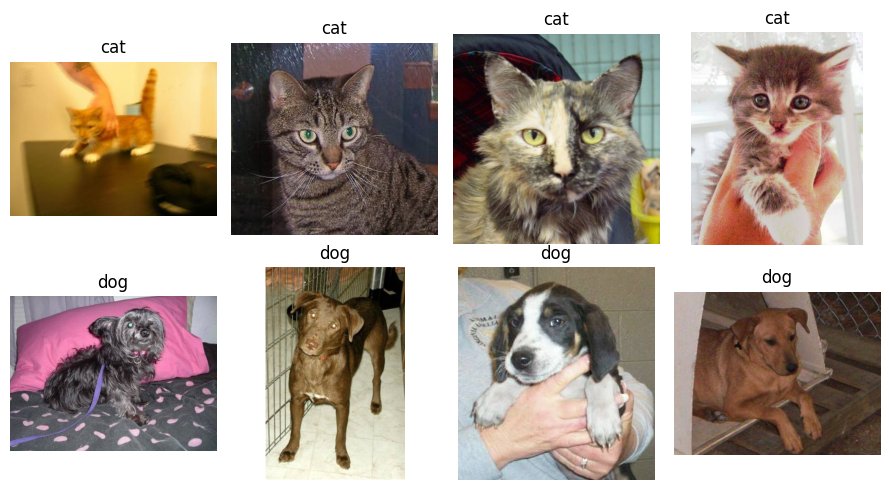

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(9, 5))
sample_paths = list(all_train_paths[all_train_labels == 0][:4]) + list(all_train_paths[all_train_labels == 1][:4])
for ax, path in zip(axes.flat, sample_paths):
    with Image.open(path) as image:
        ax.imshow(image.convert("RGB"))
    ax.set_title(path.parent.name); ax.axis("off")
plt.tight_layout(); plt.show()


## 4. train/validation/test 경계


In [6]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_train_paths, all_train_labels, test_size=.20, stratify=all_train_labels, random_state=SEED
)
print("train/validation/test:", len(train_paths), len(val_paths), len(test_paths))
print("train class count:", np.bincount(train_labels))


train/validation/test: 161 41 102
train class count: [80 81]


train 폴더만 train과 validation으로 분리합니다. test 폴더는 모델 선택이 끝난 뒤 한 번 사용합니다.


## 5. pretrained ResNet18 입력 규격


In [7]:
WEIGHTS = ResNet18_Weights.DEFAULT
print("weight URL:", WEIGHTS.url)
print("categories:", len(WEIGHTS.meta["categories"]))
print("recommended transform:", WEIGHTS.transforms())


weight URL: https://download.pytorch.org/models/resnet18-f37072fd.pth
categories: 1000
recommended transform: ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


pretrained weight는 처음 실행할 때 인터넷에서 다운로드되고 이후에는 torch cache를 사용합니다. ImageNet 학습 때 사용한 평균·표준편차와 입력 크기를 맞춰야 feature를 올바르게 활용할 수 있습니다.


## 6. 학습용 augmentation과 평가용 transform


In [8]:
IMAGE_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


## 7. transform 전후 비교


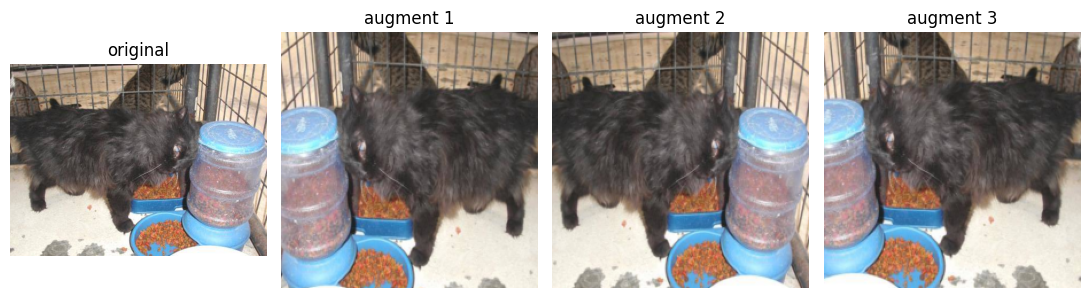

In [9]:
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1)

with Image.open(train_paths[0]) as image:
    raw_image = image.convert("RGB")
transformed = [train_transform(raw_image) for _ in range(3)]
fig, axes = plt.subplots(1, 4, figsize=(11, 3))
axes[0].imshow(raw_image); axes[0].set_title("original")
for i, tensor in enumerate(transformed, 1):
    axes[i].imshow(denormalize(tensor).permute(1, 2, 0)); axes[i].set_title(f"augment {i}")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()


좌우 반전과 crop은 Cat/Dog 의미를 유지하면서 제한된 train 이미지의 표현을 다양하게 만듭니다.


## 8. Dataset과 DataLoader


In [10]:
class CatDogDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths, self.labels, self.transform = list(paths), list(labels), transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, index):
        with Image.open(self.paths[index]) as image:
            image = image.convert("RGB")
        return self.transform(image), torch.tensor(self.labels[index], dtype=torch.long)

train_set = CatDogDataset(train_paths, train_labels, train_transform)
val_set = CatDogDataset(val_paths, val_labels, eval_transform)
test_set = CatDogDataset(test_paths, test_labels, eval_transform)
train_loader = DataLoader(train_set, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=16, shuffle=False, num_workers=0)
test_loader = DataLoader(test_set, batch_size=16, shuffle=False, num_workers=0)
images, labels = next(iter(train_loader))
print("image batch:", images.shape, images.dtype)
print("label batch:", labels.shape, labels.dtype)


image batch: torch.Size([16, 3, 224, 224]) torch.float32
label batch: torch.Size([16]) torch.int64


**Shape checkpoint ①:** ResNet18 입력은 `(N,3,224,224)`, 정답은 `(N,)`입니다.


## 9. batch 시각화


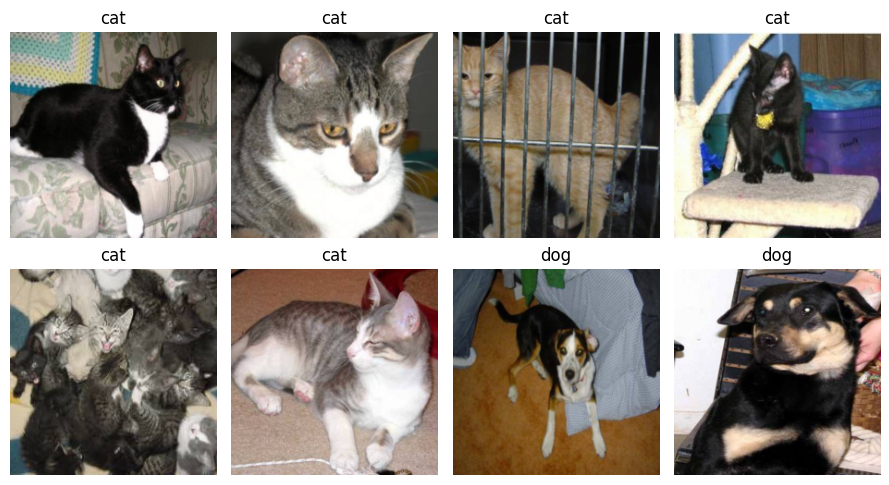

In [11]:
idx_to_class = {0: "cat", 1: "dog"}
fig, axes = plt.subplots(2, 4, figsize=(9, 5))
for ax, image, label in zip(axes.flat, images[:8], labels[:8]):
    ax.imshow(denormalize(image).permute(1, 2, 0))
    ax.set_title(idx_to_class[label.item()]); ax.axis("off")
plt.tight_layout(); plt.show()


## 10. ResNet18 다운로드와 classifier 교체


In [12]:
try:
    model = resnet18(weights=WEIGHTS)
except Exception as error:
    raise RuntimeError("ResNet18 weight 다운로드에 실패했습니다. 인터넷 연결과 인증서 설정을 확인하세요.") from error

original_features = model.fc.in_features
for parameter in model.parameters():
    parameter.requires_grad = False
model.fc = nn.Linear(original_features, 2)
model = model.to(DEVICE)
print("feature size:", original_features)
print("new classifier:", model.fc)


feature size: 512
new classifier: Linear(in_features=512, out_features=2, bias=True)


## ResNet18의 첫 Conv2d 확인

첫 층은 RGB 3채널을 64개 feature map으로 바꾸는 큰 kernel의 `Conv2d`입니다. 이후 residual block에도 여러 `Conv2d`가 포함됩니다.

In [13]:
print("first convolution:", model.conv1)
print("is Conv2d:", isinstance(model.conv1, nn.Conv2d))
print("kernel/stride/padding:", model.conv1.kernel_size, model.conv1.stride, model.conv1.padding)

first convolution: Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
is Conv2d: True
kernel/stride/padding: (7, 7) (2, 2) (3, 3)


ImageNet에서 학습한 convolution feature는 유지하고, 1,000-class classifier만 Cat/Dog 2-class classifier로 바꿉니다.


## 11. frozen parameter와 trainable parameter


In [14]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"total parameters: {total_params:,}")
print(f"trainable parameters: {trainable_params:,}")
print(f"trainable ratio: {trainable_params/total_params:.4%}")


total parameters: 11,177,538
trainable parameters: 1,026
trainable ratio: 0.0092%


## 12. 주요 block의 shape 추적


In [15]:
shape_trace = {}
hooks = []
for name in ["conv1", "maxpool", "layer1", "layer2", "layer3", "layer4", "avgpool", "fc"]:
    module = dict(model.named_modules())[name]
    hooks.append(module.register_forward_hook(lambda m, i, o, name=name: shape_trace.update({name: tuple(o.shape)})))
model.eval()
with torch.no_grad():
    sample_logits = model(images[:2].to(DEVICE))
for hook in hooks: hook.remove()
display(pd.DataFrame([{"block": name, "output shape": shape} for name, shape in shape_trace.items()]))
print("logits:", sample_logits.shape)


,block,output shape
0,conv1,"(2, 64, 112, 112)"
1,maxpool,"(2, 64, 56, 56)"
2,layer1,"(2, 64, 56, 56)"
3,layer2,"(2, 128, 28, 28)"
4,layer3,"(2, 256, 14, 14)"
5,layer4,"(2, 512, 7, 7)"
6,avgpool,"(2, 512, 1, 1)"
7,fc,"(2, 2)"


logits: torch.Size([2, 2])


**Shape checkpoint ②:** 공간 크기는 줄고 채널은 늘어나며, `avgpool` 뒤의 512차원 feature가 2개 logit으로 변환됩니다.


## 13. 학습·검증 함수


In [16]:
def set_phase_mode(model, training, phase):
    model.eval()
    if training:
        model.fc.train()
        if phase == "layer4":
            model.layer4.train()

def run_epoch(model, loader, criterion, optimizer=None, phase="head"):
    training = optimizer is not None
    set_phase_mode(model, training, phase)
    total_loss = total_correct = total_count = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        if training: optimizer.zero_grad()
        with torch.set_grad_enabled(training):
            logits = model(xb); loss = criterion(logits, yb)
            if training: loss.backward(); optimizer.step()
        total_loss += loss.item() * len(yb)
        total_correct += (logits.argmax(1) == yb).sum().item()
        total_count += len(yb)
    return total_loss / total_count, total_correct / total_count

def train_phase(model, phase, epochs, lr):
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable, lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "seconds": []}
    best_state, best_loss, best_epoch = None, float("inf"), 0
    for epoch in range(1, epochs + 1):
        started = time.perf_counter()
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, phase)
        va_loss, va_acc = run_epoch(model, val_loader, criterion, phase=phase)
        values = [tr_loss, va_loss, tr_acc, va_acc]
        for key, value in zip(list(history)[:4], values): history[key].append(value)
        history["seconds"].append(time.perf_counter() - started)
        if va_loss < best_loss:
            best_state, best_loss, best_epoch = copy.deepcopy(model.state_dict()), va_loss, epoch
        print(f"{phase} {epoch:02d} | train {tr_loss:.3f}/{tr_acc:.3f} | val {va_loss:.3f}/{va_acc:.3f}")
    model.load_state_dict(best_state)
    print("best epoch:", best_epoch)
    return history


## 14. Phase 1 · classifier head 학습


In [17]:
torch.manual_seed(SEED)
head_history = train_phase(model, phase="head", epochs=5, lr=1e-3)
criterion = nn.CrossEntropyLoss()
head_test_loss, head_test_acc = run_epoch(model, test_loader, criterion, phase="head")
head_state = copy.deepcopy(model.state_dict())
print(f"head-only test: loss={head_test_loss:.3f}, accuracy={head_test_acc:.3f}")


head 01 | train 0.462/0.832 | val 0.259/0.927


head 02 | train 0.186/0.981 | val 0.178/0.951


head 03 | train 0.132/0.975 | val 0.152/0.951


head 04 | train 0.096/0.988 | val 0.145/0.951


head 05 | train 0.073/0.994 | val 0.139/0.951
best epoch: 5


head-only test: loss=0.073, accuracy=0.980


head 학습은 pretrained feature를 바꾸지 않기 때문에 빠르고 안정적입니다. 데이터가 매우 적을 때 좋은 출발점입니다.


## 15. Phase 1 학습 곡선


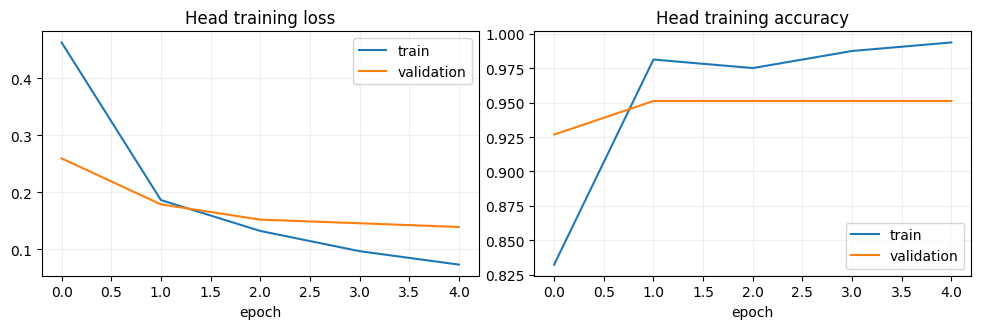

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(head_history["train_loss"], label="train"); axes[0].plot(head_history["val_loss"], label="validation")
axes[0].set_title("Head training loss")
axes[1].plot(head_history["train_acc"], label="train"); axes[1].plot(head_history["val_acc"], label="validation")
axes[1].set_title("Head training accuracy")
for ax in axes: ax.set_xlabel("epoch"); ax.legend(); ax.grid(alpha=.2)
plt.tight_layout(); plt.show()


## 16. Phase 2 · `layer4` fine-tuning 준비


In [19]:
for parameter in model.layer4.parameters():
    parameter.requires_grad = True
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"trainable after unfreezing layer4: {trainable_params:,}")


trainable after unfreezing layer4: 8,394,754


마지막 residual stage는 Cat/Dog 데이터에 맞게 조금 조정하고, 앞쪽의 일반적인 edge·texture feature는 고정합니다. pretrained feature를 크게 훼손하지 않도록 더 작은 학습률을 사용합니다.


## 17. Phase 2 · `layer4` fine-tuning


In [20]:
fine_history = train_phase(model, phase="layer4", epochs=3, lr=1e-4)
fine_test_loss, fine_test_acc = run_epoch(model, test_loader, criterion, phase="layer4")
print(f"fine-tuned test: loss={fine_test_loss:.3f}, accuracy={fine_test_acc:.3f}")


layer4 01 | train 0.091/0.969 | val 0.058/0.976


layer4 02 | train 0.045/0.994 | val 0.056/0.976


layer4 03 | train 0.017/0.994 | val 0.074/0.976
best epoch: 2


fine-tuned test: loss=0.027, accuracy=0.980


## 18. 두 단계 비교


In [21]:
phase_comparison = pd.DataFrame([
    {"phase": "head only", "trainable": model.fc.weight.numel() + model.fc.bias.numel(), "test_loss": head_test_loss, "test_accuracy": head_test_acc, "sec/epoch": np.mean(head_history["seconds"])},
    {"phase": "layer4 fine-tune", "trainable": trainable_params, "test_loss": fine_test_loss, "test_accuracy": fine_test_acc, "sec/epoch": np.mean(fine_history["seconds"])},
])
display(phase_comparison.round(3))


,phase,trainable,test_loss,test_accuracy,sec/epoch
0,head only,1026,0.073,0.98,6.617
1,layer4 fine-tune,8394754,0.027,0.98,7.717


fine-tuning이 항상 test 성능을 높이는 것은 아닙니다. 데이터 크기, domain 차이, 학습률과 validation 곡선을 함께 보고 결정합니다.


## 19. 예측 사례와 confidence


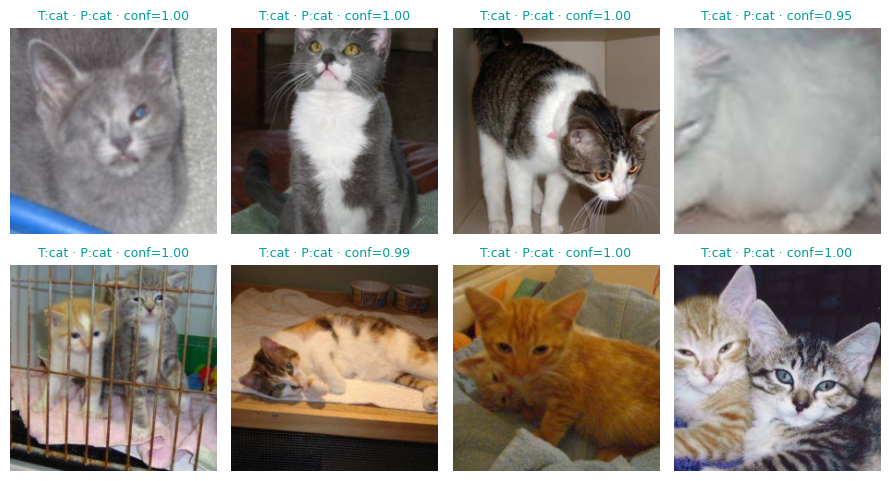

In [22]:
model.eval()
test_images, test_y = next(iter(test_loader))
with torch.no_grad():
    probabilities = model(test_images.to(DEVICE)).softmax(dim=1).cpu()
predictions = probabilities.argmax(1)
fig, axes = plt.subplots(2, 4, figsize=(9, 5))
for ax, image, true, pred, confidence in zip(axes.flat, test_images[:8], test_y[:8], predictions[:8], probabilities.max(1).values[:8]):
    ax.imshow(denormalize(image).permute(1, 2, 0))
    color = "#009E96" if true == pred else "#FF6369"
    ax.set_title(f"T:{idx_to_class[true.item()]} · P:{idx_to_class[pred.item()]} · conf={confidence:.2f}", color=color, fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()


## 20. 학습자 변경 과제

`layer4` 전체 대신 `layer4[-1]`만 학습하도록 바꾸거나, fine-tuning 학습률을 `3e-5`와 `3e-4`로 비교하세요.

기록할 내용:

1. trainable parameter 수
2. epoch 실행시간
3. validation 곡선
4. test 결과가 아니라 validation을 기준으로 선택한 이유


In [23]:
print("관찰 기록: 학습 범위는 ___, 학습률은 ___, validation 곡선은 ___했다.")


관찰 기록: 학습 범위는 ___, 학습률은 ___, validation 곡선은 ___했다.


## 현업 적용 질문·요약

- 공정 이미지가 ImageNet 사진과 매우 다르면 어느 layer까지 fine-tuning해야 할까요?
- 촬영 방향이 의미를 바꾼다면 horizontal flip을 사용해도 될까요?
- confidence가 높지만 틀린 예측을 발견하면 데이터와 모델 중 무엇부터 확인해야 할까요?

**핵심:** 작은 이미지 데이터에서는 pretrained feature를 출발점으로 삼고, validation을 보며 제한된 범위만 낮은 학습률로 조정합니다.
